<a href="https://colab.research.google.com/github/Sabari-Raj-Devarajan/EDA/blob/main/25BAI0158_EXP6_18_08_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/WineQT.csv")

print("--- FIRST 3 ROWS ---")
print(df.head(3))
print("\n--- LAST 3 ROWS ---")
print(df.tail(3))

print("\n--- DATA TYPES ---")
print(df.dtypes)

--- FIRST 3 ROWS ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  

--- LAST 3 ROWS ---
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1

In [2]:
import pandas as pd
import numpy as np

print("Checking for NaN values in the dataset:")
print(pd.isna(df).any())

target_col = 'quality'

print(f"\nDescriptive statistics for the '{target_col}' column:")
print(df[target_col].describe())

print(f"\nFirst 5 values of the '{target_col}' column after (potential) cleaning:")
print(df[target_col].head())

Checking for NaN values in the dataset:
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
Id                      False
dtype: bool

Descriptive statistics for the 'quality' column:
count    1143.000000
mean        5.657043
std         0.805824
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

First 5 values of the 'quality' column after (potential) cleaning:
0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64


Alcohol - Mean: 10.44, Median: 10.20, Mode: [9.5]


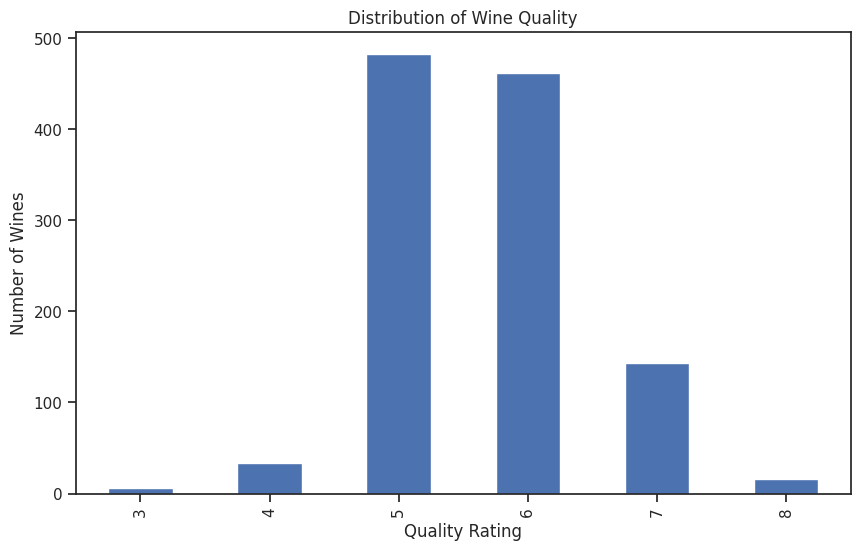

In [18]:
# Descriptive Statistics for a specific column
mean_alcohol = df["alcohol"].mean()
median_alcohol = df["alcohol"].median()
mode_alcohol = df["alcohol"].mode()
print(f"Alcohol - Mean: {mean_alcohol:.2f}, Median: {median_alcohol:.2f}, Mode: {mode_alcohol.to_list()}")

# Bar chart for categorical values (value counts)
# Using 'quality' as a categorical column
df['quality'].value_counts().sort_index().plot(kind='bar', figsize=(10,6))
plt.title("Distribution of Wine Quality")
plt.ylabel('Number of Wines')
plt.xlabel('Quality Rating')
plt.show()

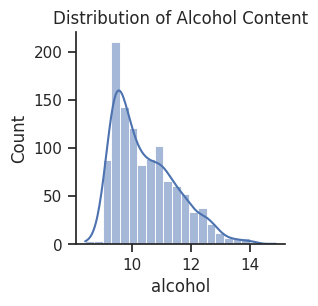

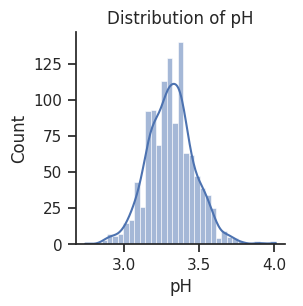

In [13]:
# Distribution plot for a numerical column (alcohol)
sns.FacetGrid(df).map(sns.histplot, "alcohol", kde=True).add_legend()
plt.title("Distribution of Alcohol Content")
plt.show()
# Distribution plot for another numerical column (pH)
sns.FacetGrid(df).map(sns.histplot, "pH", kde=True).add_legend()
plt.title("Distribution of pH")
plt.show()

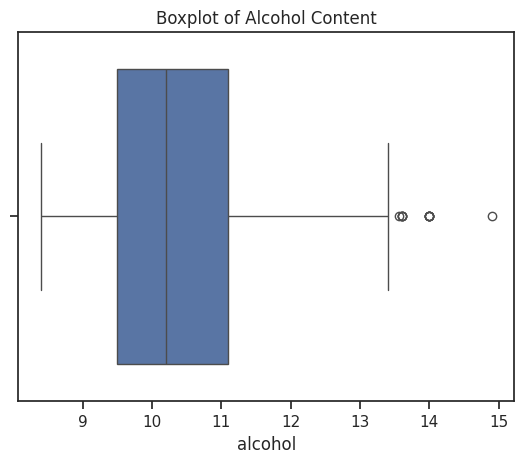

In [10]:
# Boxplot to check for summary metrics and outliers for 'alcohol'
sns.boxplot(x="alcohol", data=df)
plt.title("Boxplot of Alcohol Content")
plt.show()

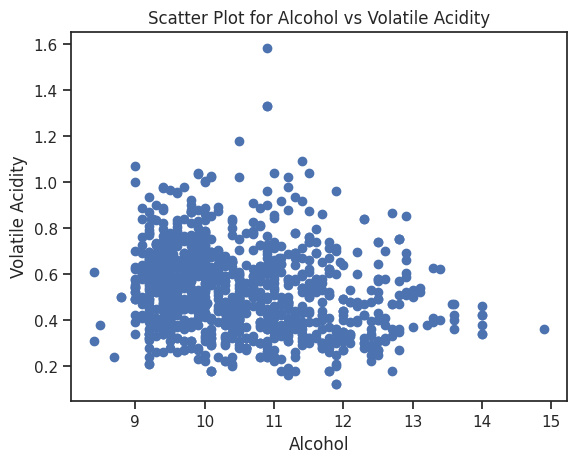

In [12]:
# Scatter Plot to analyze relationship between two numeric variables
plt.scatter(df["alcohol"], df["volatile acidity"])
plt.title("Scatter Plot for Alcohol vs Volatile Acidity")
plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.show()


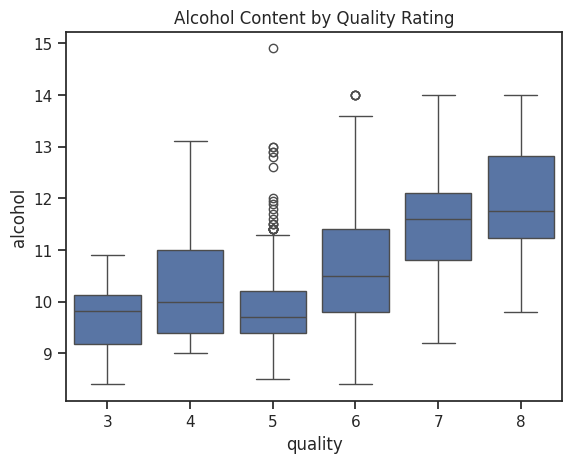

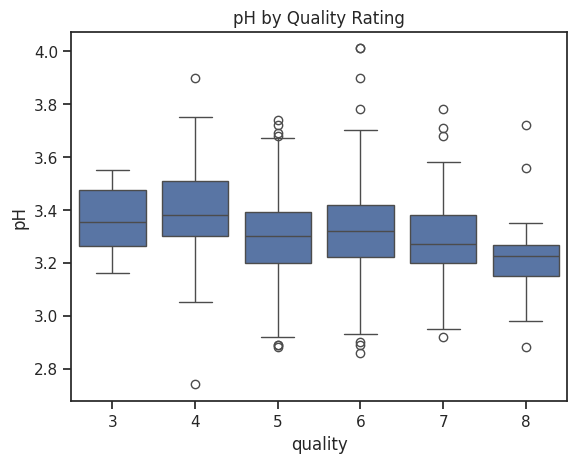

In [11]:
# Box Plot between a categorical variable and a numeric variable
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Alcohol Content by Quality Rating")
plt.show()

# Another Box Plot to visualize distribution across a different categories
sns.boxplot(x="quality", y="pH", data=df)
plt.title("pH by Quality Rating")
plt.show()

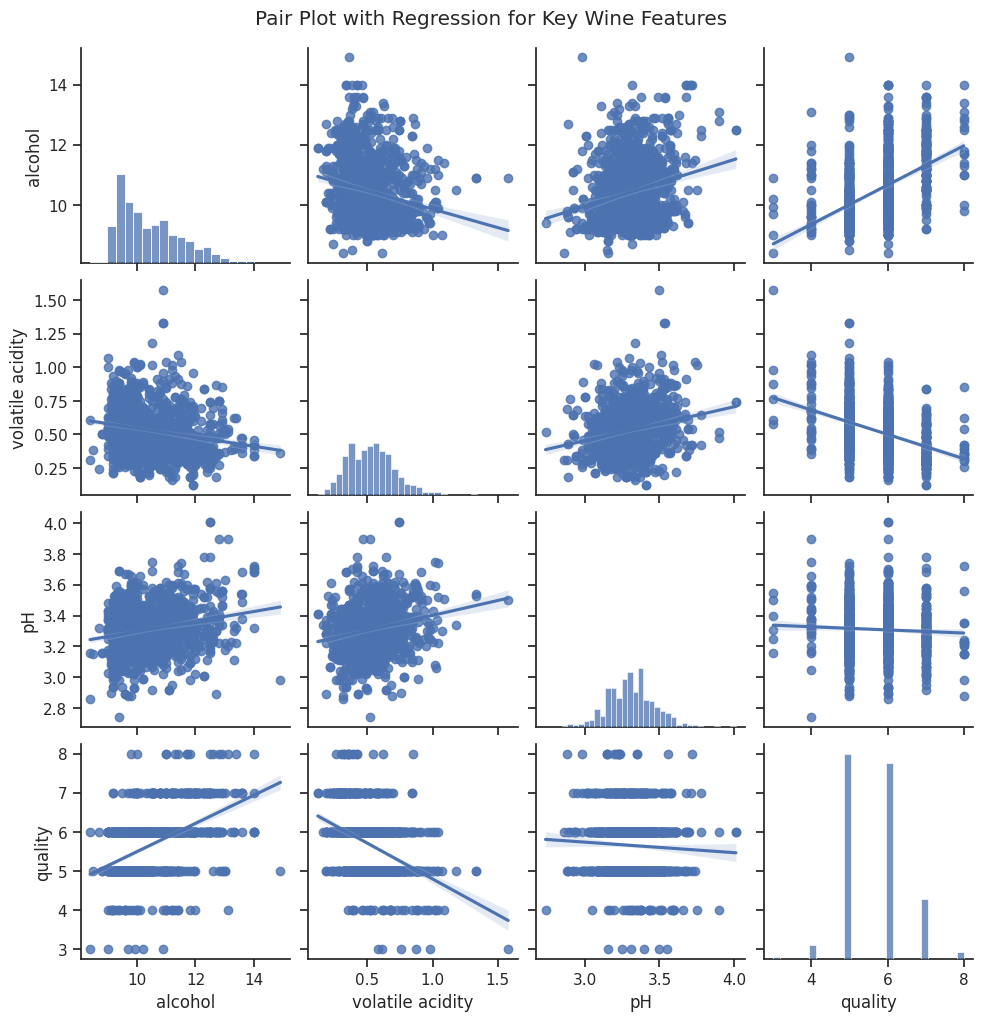

In [16]:
from scipy import stats

# Pair plot with a regression trend line for key numerical variables
sns.pairplot(df, vars=['alcohol', 'volatile acidity', 'pH', 'quality'], kind="reg")
plt.suptitle("Pair Plot with Regression for Key Wine Features", y=1.02) # Adjust suptitle position
plt.show()

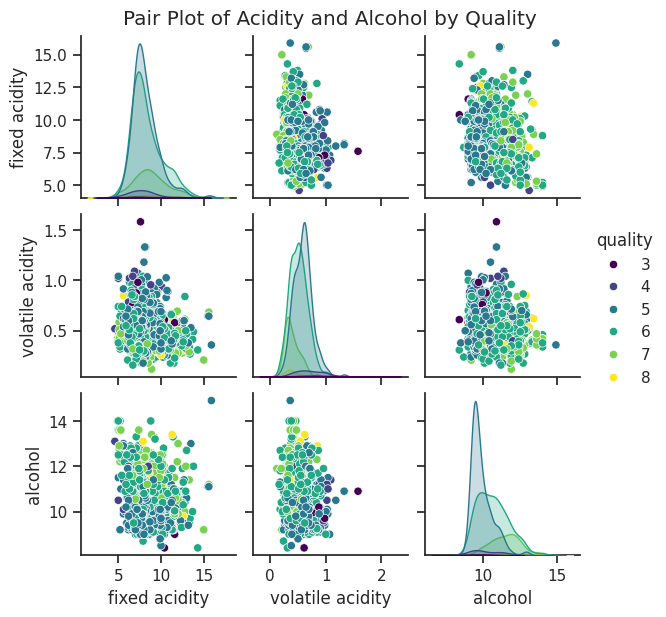

In [15]:
# Categorical matrix plot color-coded by wine quality
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['fixed acidity', 'volatile acidity', 'alcohol'], hue="quality", palette="viridis")
plt.suptitle("Pair Plot of Acidity and Alcohol by Quality", y=1.02)
plt.show()

Pearson correlation between Alcohol and Quality: 0.48
P-value for Alcohol and Quality: 0.000

Full Numeric Correlation Matrix:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.1219

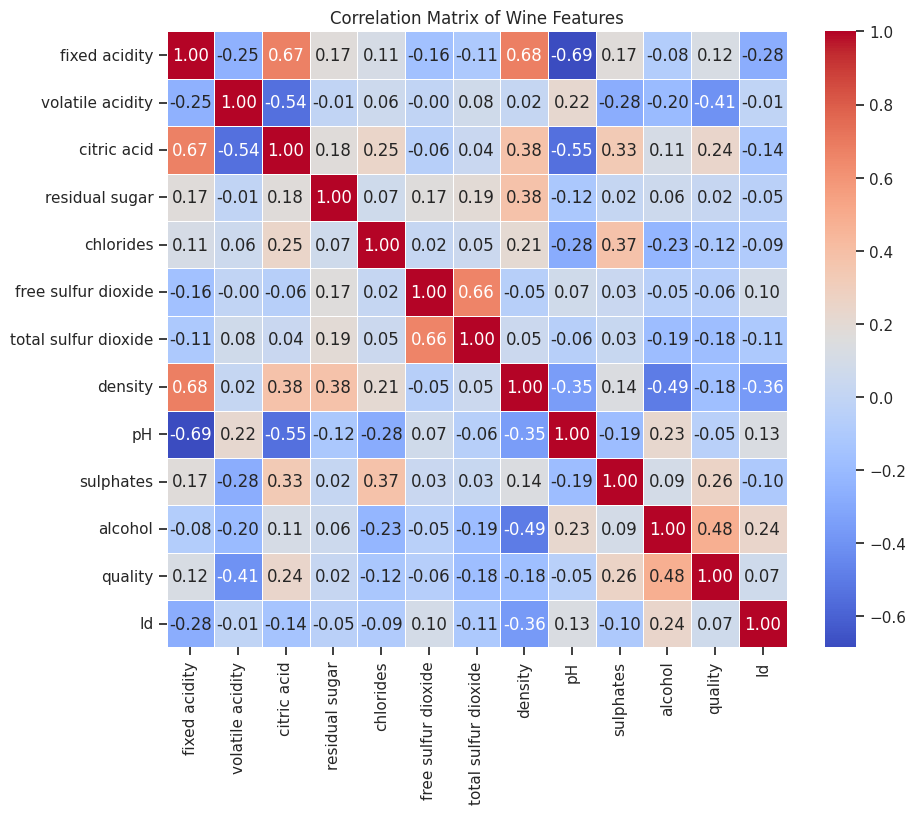

In [17]:
# Calculate specific Pearson correlation coefficient and p-value between 'alcohol' and 'quality'
corr_alcohol_quality, p_value_alcohol_quality = stats.pearsonr(df["alcohol"], df["quality"])
print(f"Pearson correlation between Alcohol and Quality: {corr_alcohol_quality:.2f}")
print(f"P-value for Alcohol and Quality: {p_value_alcohol_quality:.3f}")

# Generate full numeric correlation matrix
correlation = df.corr(method='pearson', numeric_only=True)
print("\nFull Numeric Correlation Matrix:")
print(correlation)

# Plot full analysis using a color-coded heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Wine Features")
plt.show()